# **MÓDULO 32 - Exercício**
# Random Forest


Nesta tarefa, vocês vão trabalhar com uma base de dados de avaliações de vinhos, onde o objetivo é prever a pontuação dos vinhos usando o algoritmo de Random Forest para classificação multiclasse.

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("winequality-red.csv", delimiter=',')

df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


**Vamos conhecer nossa base:**

Características dos Vinhos (Features)

Fixed Acidity: Acidez fixa do vinho.

Volatile Acidity: Acidez volátil do vinho.

Citric Acid: Quantidade de ácido cítrico no vinho.

Residual Sugar: Açúcar residual presente no vinho.

Chlorides: Nível de cloretos no vinho.

Free Sulfur Dioxide: Dióxido de enxofre livre no vinho.

Total Sulfur Dioxide: Quantidade total de dióxido de enxofre no vinho.

Density: Densidade do vinho.

pH: Nível de pH do vinho.

Sulphates: Quantidade de sulfatos no vinho.

Alcohol: Teor alcoólico do vinho.



**Variável de Saída (Target):**

Quality: Pontuação do vinho baseada em dados sensoriais, variando de 0 a 10.


Esta abordagem permitirá que vocês explorem como diferentes características químicas influenciam a qualidade dos vinhos e como o Random Forest pode ser usado para fazer previsões precisas com base nesses dados.

# 1 - Realize a primeira etapa de pré processamento dos dados.

A) Verifique os tipos de dados.


B) Verifique os dados faltantes, se houver dados faltantes faça a substituição ou remoção justificando sua escolha.

In [13]:

# Etapa 1A — Tipos de dados
print(df.shape)
print(df.info())

# Etapa 1B — Nulos
print("\nNulos:")
print(df.isnull().sum())

(1599, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None

Nulos:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          

### Etapa 1 - Pre-processamento

A) Tipos de dados: todas as features sao float64 e a
target quality e int64. Os tipos estao corretos e nao
precisam de conversao.

B) Dados faltantes: nenhum nulo encontrado em nenhuma
das 12 colunas. Nenhuma acao necessaria.

# 2 - Realize a segunda e terceita etapa de pré processamento dos dados.

A) Utilize a função describe para identificarmos outliers e verificarmos a distribuição dos dados.

B) Verifique o balanceamento da váriavel Target.

C)  Plote o gráfico ou a tabela e indique as variáveis que te parecem mais "fortes" na correlação para nosso modelo.

D) Crie um novo dataframe apenas com as váriaveis que parecem ter maior correlação com a target. (Negativa ou positiva)


       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1599.000000          1599.000000           1599.000000  1599.000000   
mean      0.087467            15.874922             46.467792     0.996747   
std       0.047065            10.460157             32.895324     0.001887   
min       0.012000             1.000000         

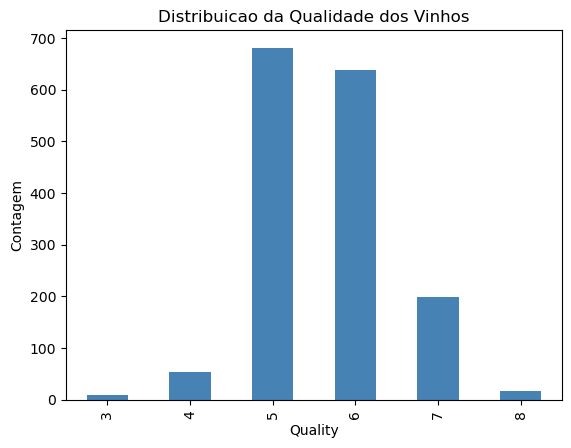

In [15]:
# 2A — Describe
print(df.describe())

# 2B — Balanceamento da target
print("\nBalanceamento da target:")
print(df['quality'].value_counts().sort_index())
print("\n%:")
print(df['quality'].value_counts(normalize=True).mul(100).round(1).sort_index())

# Grafico
df['quality'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Distribuicao da Qualidade dos Vinhos')
plt.xlabel('Quality')
plt.ylabel('Contagem')
plt.show()

### Etapa 2A - Describe

Pontos de atencao nos dados:
- residual sugar: max 15.5 muito acima do 75% (2.6), outliers
- chlorides: max 0.611 muito acima do 75% (0.090), outliers
- total sulfur dioxide: max 289 muito acima do 75% (62), outliers
- sulphates: max 2.0 acima do 75% (0.73), outliers moderados

### Etapa 2B - Balanceamento da Target

A base e fortemente desbalanceada:
- Classes 5 e 6 dominam com 82.5% dos dados juntas
- Classes 3 e 8 sao extremamente raras (0.6% e 1.1%)
- Classes 4 e 7 tem representacao baixa (3.3% e 12.4%)

Isso significa que o modelo tera dificuldade para prever
vinhos de qualidade muito baixa (3,4) ou muito alta (7,8)
pois tem poucos exemplos para aprender.

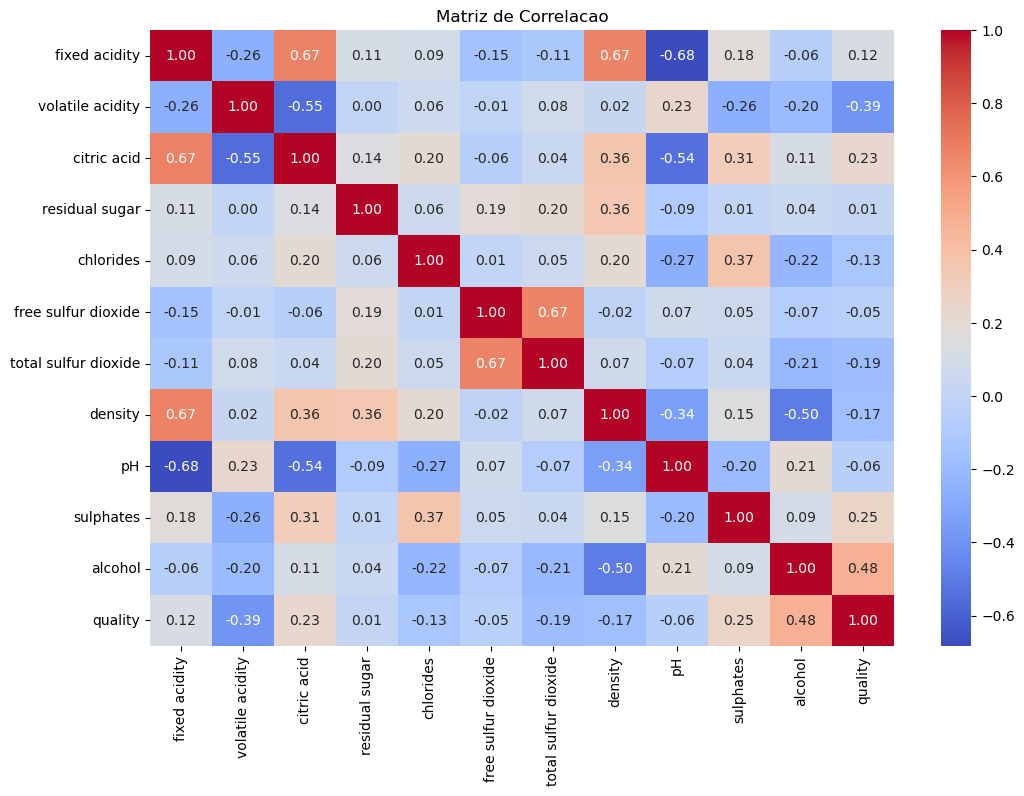


Correlacao com quality:
quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


In [18]:
correlacao = df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlacao')
plt.show()

# Mostrar correlacao com quality especificamente
print("\nCorrelacao com quality:")
print(correlacao['quality'].sort_values(ascending=False))

### Etapa 2C - Correlacao com Quality

Correlacoes positivas mais fortes:
- alcohol (0.48): maior preditor de qualidade.
  Vinhos com maior teor alcoolico tendem a ter
  melhor avaliacao.
- sulphates (0.25): sulfatos em nivel adequado
  contribuem positivamente para a qualidade.
- citric acid (0.23): acido citrico adiciona
  frescor e sabor ao vinho.

Correlacoes negativas mais fortes:
- volatile acidity (-0.39): acidez volatil alta
  gera sabor de vinagre, prejudicando a qualidade.
- total sulfur dioxide (-0.19): excesso de dioxido
  de enxofre afeta negativamente o sabor.
- density (-0.17): densidade alta esta associada
  a menor qualidade.

In [21]:
# Selecionar variaveis com correlacao acima de 0.15 (positiva ou negativa)
cols_selecionadas = ['alcohol', 'sulphates', 'citric acid',
                     'volatile acidity', 'total sulfur dioxide',
                     'density', 'quality']

df_filtrado = df[cols_selecionadas]

print("Shape do dataframe filtrado:", df_filtrado.shape)
print(df_filtrado.head())

Shape do dataframe filtrado: (1599, 7)
   alcohol  sulphates  citric acid  volatile acidity  total sulfur dioxide  \
0      9.4       0.56         0.00              0.70                  34.0   
1      9.8       0.68         0.00              0.88                  67.0   
2      9.8       0.65         0.04              0.76                  54.0   
3      9.8       0.58         0.56              0.28                  60.0   
4      9.4       0.56         0.00              0.70                  34.0   

   density  quality  
0   0.9978        5  
1   0.9968        5  
2   0.9970        5  
3   0.9980        6  
4   0.9978        5  


# 3 - Preparação Final dos Dados

A) Separe a base em X(Features) e Y(Target)

B) Separe a base em treino e teste.


In [23]:
# A) Separar X e y
X = df_filtrado.drop(columns=['quality'])
y = df_filtrado['quality']

# B) Separar treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1279, 6)
X_test: (320, 6)
y_train: (1279,)
y_test: (320,)


# 4 - Modelagem

A) Inicie e treine o modelo de Random Forest

B) Aplique a base de teste o modelo.


In [25]:
# A) Treinar o modelo
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# B) Aplicar na base de teste
y_pred = rf.predict(X_test)

print("Modelo treinado e aplicado com sucesso!")
print("Primeiras previsoes:", y_pred[:10])
print("Valores reais:      ", y_test.values[:10])

Modelo treinado e aplicado com sucesso!
Primeiras previsoes: [5 5 5 5 6 5 5 5 6 6]
Valores reais:       [6 5 6 5 6 5 5 5 5 6]


# 5 - Avaliação

A) Avalie as principais métricas da Claissificação e traga insights acerca do resultado, interprete os valores achados.

B) Você nota que o modelo teve dificuldade para prever alguma classe? Se sim, acredita que tenha relação com o balanceamento dos dados? Explique.


Acuracia: 0.675

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.73      0.80      0.76       130
           6       0.65      0.69      0.67       132
           7       0.62      0.50      0.55        42
           8       0.00      0.00      0.00         5

    accuracy                           0.68       320
   macro avg       0.33      0.33      0.33       320
weighted avg       0.64      0.68      0.66       320



C:\Users\Cliente\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Cliente\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Cliente\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


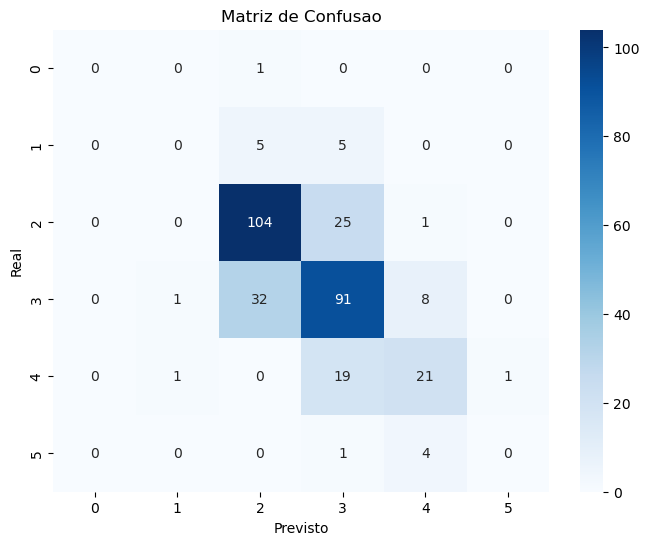

In [27]:
# A) Metricas
print("Acuracia:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Matriz de confusao
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusao')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.show()


**A) Metricas**

Acuracia: 67.5%

O modelo teve desempenho razoavel para as classes
majoritarias:
- Classe 5: F1-score 0.76 (130 exemplos no teste)
- Classe 6: F1-score 0.67 (132 exemplos no teste)
- Classe 7: F1-score 0.55 (42 exemplos no teste)

**B) Dificuldade com classes minoritarias**

O modelo nao conseguiu prever nenhum caso das classes
3, 4 e 8, com F1-score de 0.00 para todas elas.

Isso tem relacao direta com o desbalanceamento da base:
- Classe 3: apenas 10 registros no treino
- Classe 4: apenas 53 registros no treino
- Classe 8: apenas 18 registros no treino

O modelo nunca viu exemplos suficientes dessas classes
para aprender a identifica-las. Com dados tao escassos,
o algoritmo opta por classificar esses casos como classe
5 ou 6, que sao as mais comuns.

O warning de UndefinedMetricWarning confirma isso:
o modelo nao fez nenhuma previsao para essas classes,
tornando a precision indefinida.

# 5 - Melhorando os Hyperparametros

A) Defina o Grid de parametros que você quer testar

B) Inicie e Treine um novo modelo utilizando o random search.

C) Avalie os resultados do modelo.

D) Você identificou melhorias no modelo após aplicar o random search? Justifique.


ps. Essa parte da atividade demorará um pouco para rodar!

In [30]:
# A) Grid de parametros
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# B) Treinar com RandomizedSearch
rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_random.fit(X_train, y_train)

print("Melhores parametros:")
print(rf_random.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Melhores parametros:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}


Acuracia novo modelo: 0.6562

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.71      0.78      0.74       130
           6       0.62      0.67      0.64       132
           7       0.64      0.50      0.56        42
           8       0.00      0.00      0.00         5

    accuracy                           0.66       320
   macro avg       0.33      0.32      0.32       320
weighted avg       0.62      0.66      0.64       320



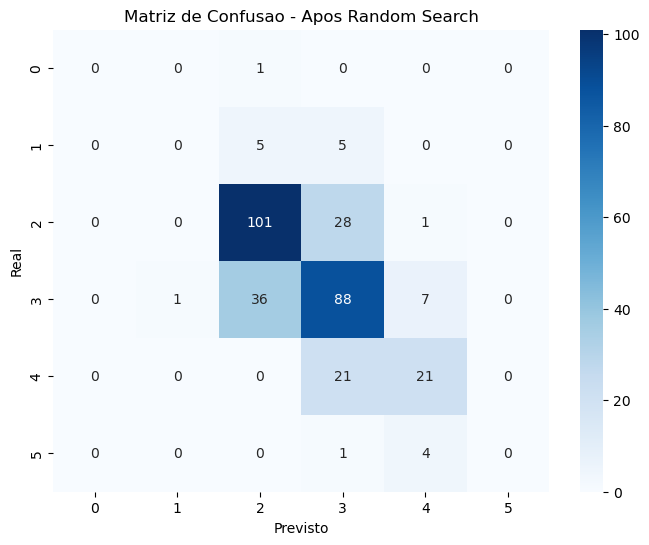

In [32]:
# C) Avaliar o novo modelo
y_pred_random = rf_random.predict(X_test)

print("Acuracia novo modelo:", round(accuracy_score(y_test, y_pred_random), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_random, zero_division=0))

# Matriz de confusao
plt.figure(figsize=(8, 6))
cm2 = confusion_matrix(y_test, y_pred_random)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusao - Apos Random Search')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.show()

### Etapa 5 - Melhorando com Random Search

**Melhores parametros encontrados:**
- n_estimators: 200
- min_samples_split: 5
- min_samples_leaf: 1
- max_features: sqrt
- max_depth: None

**C) Avaliacao do novo modelo**

Acuracia antes: 67.5%
Acuracia depois: 65.6%

**D) Houve melhoria?**

Nao. O Random Search resultou em uma leve queda de
desempenho (67.5% para 65.6%). As classes minoritarias
(3, 4 e 8) continuaram com F1-score zero, confirmando
que o problema nao esta nos hiperparametros mas sim
no desbalanceamento da base.

O modelo original com parametros padrao ja estava
levemente melhor calibrado para essa base. Isso mostra
que o Random Search nao e uma solucao garantida e que
o desbalanceamento e o problema principal a resolver.

# 6 - Chegando a perfeição

Baseado em tudo que você já aprendeu até agora, quais outras técnicas você acredita que poderiam ser aplicadas ao modelo para melhorar ainda mais suas previsões?

### Etapa 6 - Chegando a Perfeicao

Tecnicas que poderiam melhorar o modelo:

1. Balanceamento com SMOTE: aplicar SMOTE na base de
   treino para gerar exemplos sinteticos das classes
   minoritarias (3, 4 e 8) que o modelo nao conseguiu
   aprender. Esse e o principal problema a resolver.

2. Agrupar classes similares: ao inves de prever 6
   classes, criar 3 grupos: baixa qualidade (3,4),
   media qualidade (5,6) e alta qualidade (7,8). Isso
   reduziria o desbalanceamento e tornaria o problema
   mais tratavel.

3. Testar outros algoritmos: XGBoost ou LightGBM
   lidam melhor com desbalanceamento e tendem a superar
   o Random Forest em problemas multiclasse com classes
   raras.

4. Engenharia de features: criar novas variaveis
   combinando as existentes, como a razao entre
   alcohol e volatile acidity, pode revelar padroes
   que as variaveis originais nao capturam sozinhas.